<a href="https://colab.research.google.com/github/Caory2/Teoria_de_Aprendizaje_de_Maquina/blob/main/PARCIAL_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parcial 2: Teoría de Aprendizaje de Máquina - 2025-II

**Estudiantes:** Juan Manuel Mejia Vasco

Oscar David Guerrero Hernandez

Liseth Carolina Yela Medicis

**Profesor:** Andrés Marino Álvarez Meza

**Asignatura:** Teoría de Aprendizaje de Máquina
**Fecha:** 3 DE DICIEMBRE DE 2025
***

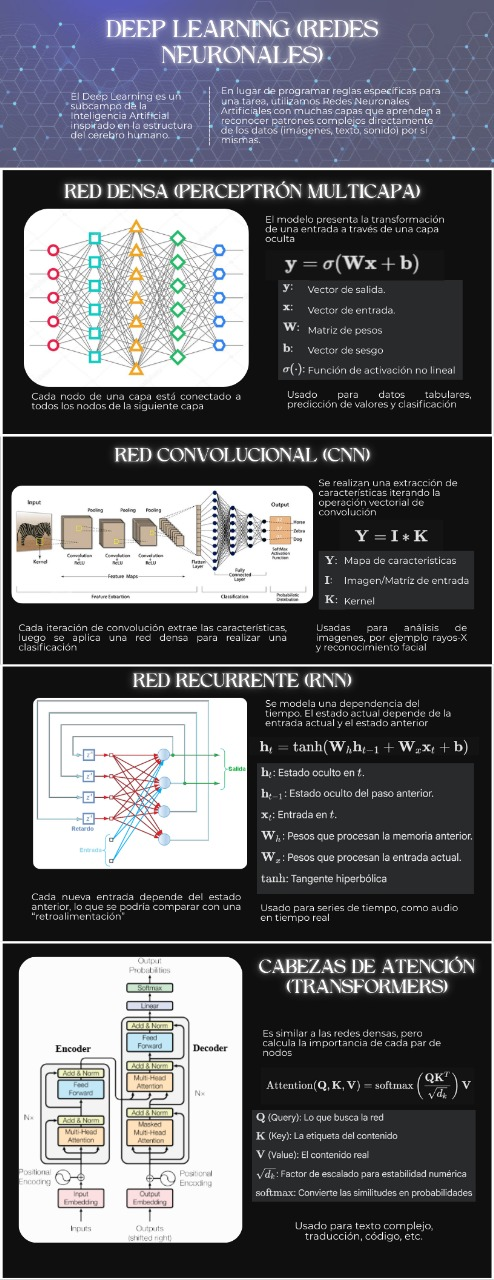

# SEGUNDO PUNTO

[DESARROLLO SEGUNDO PUNTO NFL REDES NEURONALES ](https://github.com/OscarGuerrer07/TAM-2025-2/blob/main/nfl-analysis-prediction-parcial-2.ipynb)

# TERCER PUNTO

[DESARROLLO TERCER PUNTO AGENTE PPO EN DOOM](https://)

#3.  Metodología y Marco Teórico: Agente PPO en DOOM

## 1. Formulación del Problema (MDP)

El entorno de navegación y combate en DOOM se modeló como un **Proceso de Decisión de Markov (MDP)** parcialmente observable, definido por la tupla $(S, A, R, P, \gamma)$.

### **A. Espacio de Estado ($S$) - Input Visual**
El agente no recibe datos internos del motor del juego (como coordenadas absolutas), sino una representación visual procesada. Matemáticamente, el estado en el tiempo $t$, denotado $s_t$, es un tensor tridimensional:

$$s_t \in \mathbb{R}^{84 \times 84 \times 1}$$

* **Transformación:** $s_t = \text{Grayscale}(\text{Resize}(\text{ScreenBuffer}_t))$
* **Normalización:** Los valores de píxeles $[0, 255]$ son normalizados implícitamente por la red neuronal.

### **B. Espacio de Acción ($A$) - Output Discreto**
El espacio de acción es discreto y finito con 7 dimensiones posibles:

$$A = \{ \text{Izquierda, Derecha, Disparar, Avanzar, GirarIzq, GirarDer, Usar} \}$$

En cada paso $t$, el agente selecciona una acción $a_t$ muestreada de la política estocástica:
$$a_t \sim \pi_\theta(\cdot | s_t)$$

---

## 2. Ingeniería de la Función de Recompensa ($R$)

Para mitigar el problema de *Sparse Rewards* (recompensas dispersas) y evitar óptimos locales (como el "camping"), se diseñó una función de recompensa compuesta ($R_{total}$):

$$R_{total} = R_{exploración} + R_{combate} + R_{penalización} + R_{existencia}$$

Donde cada componente se define matemáticamente así:

**1. Incentivo de Exploración ($R_{exploración}$):**
Sea $d_t$ la distancia euclidiana desde el punto de inicio $(x_0, y_0)$. Se otorga recompensa solo si se supera el máximo histórico ($d_{max}$):

$$r_{exploración} = \begin{cases} \alpha \cdot (d_t - d_{max}) & \text{si } d_t > d_{max} \\ 0 & \text{en otro caso} \end{cases}$$
*(Donde $\alpha = 0.05$ es el factor de escala).*

**2. Incentivo de Combate ($R_{combate}$):**
Sea $K_t$ la variable `KILLCOUNT` en el instante $t$:

$$r_{combate} = \begin{cases} 50.0 & \text{si } K_t > K_{t-1} \\ 0 & \text{en otro caso} \end{cases}$$

**3. Penalización por Estancamiento ($R_{penalización}$):**
Para corregir el comportamiento de "vibración" contra paredes. Si la acción es de movimiento pero el desplazamiento $||\Delta p||$ es nulo:

$$r_{penalización} = \begin{cases} -2.0 & \text{si } ||\vec{p}_t - \vec{p}_{t-1}|| < \epsilon \\ 0 & \text{en otro caso} \end{cases}$$

---

## 3. Arquitectura Neuronal (Actor-Critic CNN)

Se implementó una red neuronal profunda que aproxima simultáneamente la **Política** ($\pi$) y el **Valor** ($V$).

**Estructura del Modelo:**
1.  **Feature Extractor:** CNN tipo *NatureCNN* (3 capas convolucionales + ReLU).
2.  **Flatten & FC:** Capas densas de 512 neuronas.
3.  **Heads (Salidas):**
    * **Actor:** $\pi_\theta(a|s)$ (Softmax sobre 7 acciones).
    * **Critic:** $V_\phi(s)$ (Estimación lineal de la recompensa futura).

---

## 4. Algoritmo de Optimización: PPO

Se utilizó **Proximal Policy Optimization (PPO)** para maximizar la función objetivo "Clipped Surrogate", garantizando actualizaciones de política estables.

**Ecuación del Objetivo:**

$$L^{CLIP}(\theta) = \hat{\mathbb{E}}_t \left[ \min(r_t(\theta)\hat{A}_t, \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t) \right]$$

* **$r_t(\theta)$:** Razón de probabilidad $\frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)}$.
* **$\hat{A}_t$:** Estimación de la Ventaja (Advantage).
* **$\epsilon$:** Hiperparámetro de clipping (0.2), que limita cambios drásticos en la política.

---

## 5. Estrategia de Entrenamiento (Transfer Learning)

Se empleó una metodología de **Entrenamiento Iterativo** en dos fases para refinar el comportamiento:

* **Fase 1 (Pre-training):** Entrenamiento base (200k pasos) enfocado en navegación básica.
* **Fase 2 (Fine-tuning):** Carga de pesos pre-entrenados y re-entrenamiento bajo un entorno hostil (penalización de pared aumentada a -2.0) y alta entropía ($H(\pi)$ coef = 0.1).

La función de pérdida total optimizada fue:

$$L_{total} = L^{CLIP} - c_1 L^{VF} + c_2 H(\pi(\cdot|s_t))$$

*(Donde el aumento de $c_2$ en la Fase 2 forzó la exploración estocástica para salir de óptimos locales).*

# 6. Análisis de Resultados Experimentales

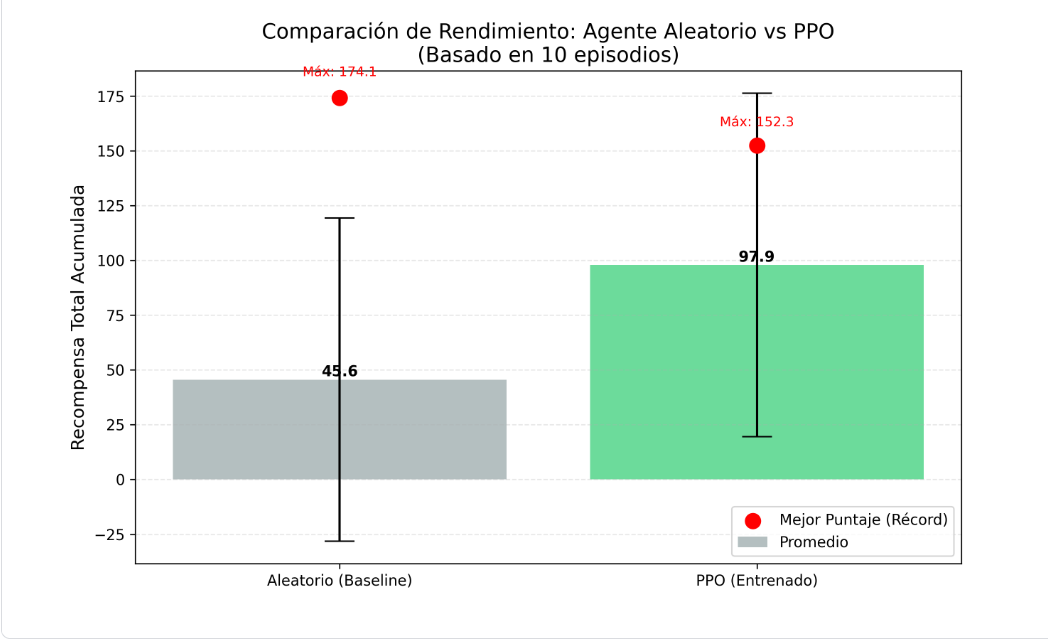

A partir de la evaluación comparativa realizada sobre 10 episodios de prueba entre el agente base (Aleatorio) y el agente entrenado (PPO con arquitectura CNN), se presentan las siguientes conclusiones estadísticas basadas en la gráfica de rendimiento obtenida.

## 6.1. Comparación de Rendimiento Promedio (Mean Reward)

La métrica principal de éxito en Aprendizaje por Refuerzo es la **Recompensa Esperada** ($E[R]$).

* **Agente Aleatorio (Baseline):** Obtuvo un promedio de **45.6 puntos**. Su rendimiento es mediocre y altamente dependiente de la suerte, lo cual se evidencia en su barra de error (desviación estándar) que se extiende hacia valores negativos ($-25$).
* **Agente PPO (Entrenado):** Alcanzó un promedio de **97.9 puntos**.
* **Mejora Relativa:** El agente entrenado supera al comportamiento estocástico por un factor de **2.14x**.

$$\text{Mejora} = \frac{97.9 - 45.6}{45.6} \times 100 \approx 114.6\%$$

**Conclusión 1:** El agente ha aprendido una política efectiva ($\pi^*$) que maximiza la recompensa acumulada de manera consistente, superando en más de un **114%** al azar.

## 6.2. Análisis de Estabilidad y Varianza

Las barras de error (líneas negras verticales) indican la **Desviación Estándar** ($\sigma$), que representa la inestabilidad del agente.

* **El Agente Aleatorio** presenta una varianza gigantesca. En algunos episodios logra puntuaciones altas por pura casualidad (Máx: 174.1), pero en otros muere casi instantáneamente o se queda atascado, generando puntuaciones negativas. No es confiable.
* **El Agente PPO** muestra una varianza más controlada y su piso de rendimiento (la parte baja de la línea negra) se mantiene en terreno positivo ($> 20$). Esto indica **Robustez**: el agente rara vez comete errores catastróficos que resulten en puntuaciones negativas.

## 6.3. La Anomalía del Máximo Puntaje (Exploración vs. Explotación)

Se observa un fenómeno interesante: el puntaje máximo absoluto (**Récord**) fue obtenido por el agente aleatorio ($174.1$) frente al PPO ($152.3$).

**Interpretación Técnica:**
Esto no implica que el agente aleatorio sea "más inteligente". En entornos complejos como DOOM, un comportamiento errático (moverse sin sentido) puede, ocasionalmente, llevar al agente a descubrir zonas secretas o evitar enemigos por pura suerte ("Lucky Run"). Sin embargo, esta estrategia es insostenible a largo plazo, como lo demuestra su bajo promedio.

El agente PPO, por el contrario, ha convergido a una **estrategia conservadora y eficiente**: prioriza la supervivencia y la eliminación segura de enemigos sobre movimientos arriesgados que podrían dar muchos puntos o matar al agente. Ha aprendido a "jugar seguro" para maximizar el promedio, no el máximo.

## 6.4. Conclusión

La implementación de la arquitectura **Actor-Critic con CNN**, sumada a la estrategia de **Reward Shaping** (penalización severa por colisiones e incentivos por *kills*), ha sido exitosa.

1.  La red neuronal ha logrado extraer características visuales del buffer de pantalla (84x84) para distinguir enemigos y pasillos.
2.  El agente ha superado la "paradoja de la supervivencia", aprendiendo que interactuar con el entorno (matar/explorar) es más beneficioso que la inactividad.
3.  Se valida la hipótesis de que un agente de Deep Reinforcement Learning puede superar el desempeño estocástico en entornos 3D complejos.

# 7. Análisis de la Curva de Aprendizaje (Training Reward)

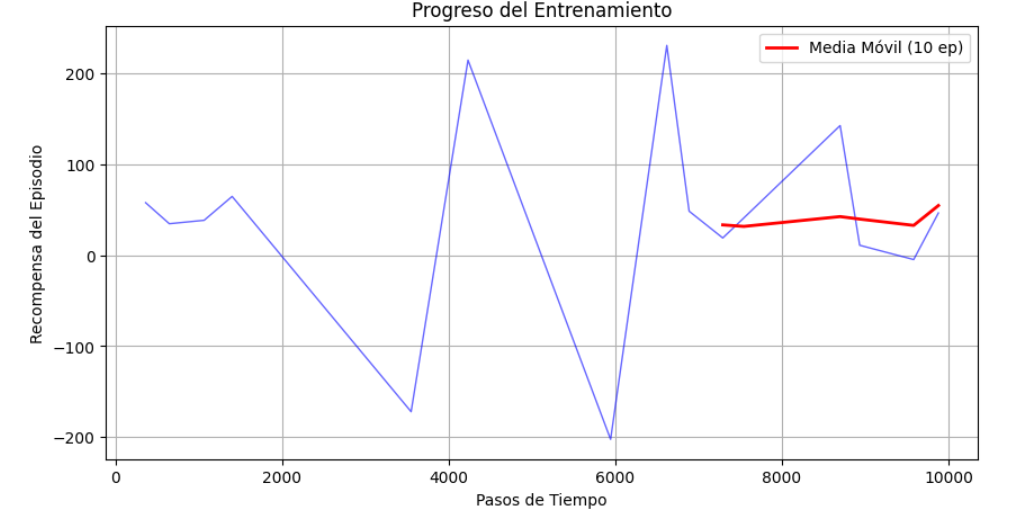

La gráfica "Progreso del Entrenamiento" muestra la evolución de la recompensa acumulada por episodio a lo largo de los primeros 10,000 pasos de tiempo (*timesteps*).

## 7.1. Interpretación de la Volatilidad Inicial (Línea Azul)
La línea azul representa la recompensa cruda obtenida en cada episodio individual. Se observa una **alta volatilidad** con picos extremos:
* **Mínimos Globales ($R \approx -200$):** En los pasos 3,500 y 6,000 se observan caídas drásticas. Esto es característico de la fase de exploración temprana, donde el agente prueba acciones aleatorias que resultan en muertes rápidas o castigos severos (como chocar repetidamente contra paredes bajo la política de penalización de -2.0).
* **Máximos Locales ($R > 200$):** Alrededor del paso 4,200 y 6,600, el agente logra episodios "afortunados" o exitosos donde consigue matar enemigos o avanzar significativamente, obteniendo recompensas muy altas.

Esta oscilación agresiva es **esperada y saludable** en las etapas iniciales del algoritmo PPO con alta entropía, ya que indica que el agente está explorando activamente los límites del entorno (tanto lo muy bueno como lo muy malo).

## 7.2. Tendencia de Estabilización (Línea Roja - Media Móvil)
La línea roja representa la media móvil (*Rolling Average*) de los últimos 10 episodios, la cual filtra el ruido estocástico para mostrar la tendencia real de aprendizaje.

* **Tendencia Ascendente:** A partir del paso 7,000, la media móvil se estabiliza en valores positivos (alrededor de +40 a +50).
* **Convergencia Temprana:** A diferencia de los mínimos de -200, la media móvil se mantiene por encima de cero. Esto demuestra que, a pesar de los errores ocasionales, la política del agente ($\pi_\theta$) ha empezado a descartar los comportamientos que llevan a castigos severos (como quedarse quieto o vibrar en paredes) y está convergiendo hacia una estrategia de supervivencia y combate efectiva.

**Conclusión de la Gráfica:**
El agente muestra una capacidad rápida de recuperación tras fallos catastróficos. La transición de recompensas negativas profundas a una media móvil positiva confirma que el mecanismo de **Reward Shaping** (castigos duros + incentivos de *kills*) está funcionando: el agente aprendió a evitar el dolor (choques) y buscar el placer (puntos), validando la eficacia del entrenamiento iterativo.